In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

df = pd.DataFrame({
    'Age': np.random.randint(18, 60, size=100),
    'Salary': np.random.randint(20000, 150000, size=100),
    'Experience': np.random.randint(0, 20, size=100),
    'Department': np.random.choice(['HR', 'IT', 'Sales'], size=100),
    'Duplica_Salary': None,  # placeholder, we'll copy later
    'Constant': 5,             # constant column (0 variance)
    'Almost_Constant': np.random.choice([1, 1, 1, 2], size=100)


    # Useless features

})

# Add duplicate column
df['Duplicate_Salary'] = df['Salary']
df['Target'] =  np.random.choice([0, 1], size=100)


In [ ]:
def get_duplicate_columns(df):

    duplicate_columns = {}
    seen_columns = {}

    for column in df.columns:
        current_column = df[column]

        # Convert column data to bytes
        try:
            current_column_hash = current_column.values.tobytes()
        except AttributeError:
            current_column_hash = current_column.to_string().encode()

        if current_column_hash in seen_columns:
            if seen_columns[current_column_hash] in duplicate_columns:
                duplicate_columns[seen_columns[current_column_hash]].append(column)
            else:
                duplicate_columns[seen_columns[current_column_hash]] = [column]
        else:
            seen_columns[current_column_hash] = column

    return duplicate_columns

In [ ]:
from sklearn.feature_selection import  VarianceThreshold
from sklearn.model_selection import train_test_split
y = df['Target']

mask = ~df.columns.isin(['Duplica_Salary','Department'])
temp = df[df.columns[mask]]


In [ ]:
temp = temp.iloc[:,:-1]

In [ ]:
sel = VarianceThreshold(threshold = 1)
sel.fit(temp)
# Getting columsn that support it
statisfied_cols = temp.columns[sel.get_support()]
temp[statisfied_cols]


,Age,Salary,Experience,Duplicate_Salary
0,56,28392,4,28392
1,46,50535,0,50535
2,32,98603,18,98603
3,25,133569,9,133569
4,38,72256,11,72256
...,...,...,...,...
95,59,125830,17,125830
96,56,78053,13,78053
97,58,41959,17,41959
98,45,25530,1,25530


In [ ]:
array = sel.transform(temp) # same as aboce but 1 less line
temp = pd.DataFrame(data = array , columns =statisfied_cols )

In [ ]:
# co relation
mat = temp.corr()
drop = []
columns = mat.columns
for i in range(len(columns)) :
  for j in range(i+1 , len(columns)) :
    if mat.loc[columns[i], columns[j]]>0.95:
      drop.append(columns[j])



drop = list(set(drop))
# temp[temp.columns[~temp.columns.isin(['Duplicate_Salary'])]]
#or
temp = temp.drop(columns=drop)

In [ ]:
from sklearn.feature_selection import SelectKBest , f_classif

In [ ]:
temp = temp.drop(columns=['Target'])

In [ ]:
sel = SelectKBest(f_classif , k =2  )
sel.fit(temp , y)

SelectKBest(k=2)

In [ ]:
# now clunns
cols= temp.columns[sel.get_support()]
array = sel.transform(temp)
temp = pd.DataFrame(data = array , columns = cols)
temp

,Age,Salary
0,56,28392
1,46,50535
2,32,98603
3,25,133569
4,38,72256
...,...,...
95,59,125830
96,56,78053
97,58,41959
98,45,25530


In [ ]:
import pandas as pd
import numpy as np
np.random.seed(42)

# ----- Generate synthetic categorical data -----
n_samples = 100
data = pd.DataFrame({
    'Gender': np.random.choice(['Male', 'Female'], n_samples),
    'Education': np.random.choice(['High School', 'Bachelors', 'Masters', 'PhD'], n_samples),
    'Marital_Status': np.random.choice(['Single', 'Married', 'Divorced'], n_samples),
    'Employed': np.random.choice(['Yes', 'No'], n_samples),
    'Owns_House': np.random.choice(['Yes', 'No'], n_samples),
    'Target': np.random.choice(['Buy', 'Not Buy'], n_samples)
})

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest , chi2



In [ ]:
label_encoder={}
for col in data.columns:
  le = LabelEncoder()
  data[col] = le.fit_transform(data[col])
  label_encoder[col] =  le


In [ ]:
x = data.iloc[:,:-1]
y = data.iloc[:,-1]


In [ ]:
chi , p = chi2(x,y)


In [ ]:
import matplotlib.pyplot as plt


Index(['Gender', 'Education', 'Marital_Status', 'Employed', 'Owns_House'], dtype='object')

In [ ]:
sr.sort_values(inplace = True)

<Axes: >

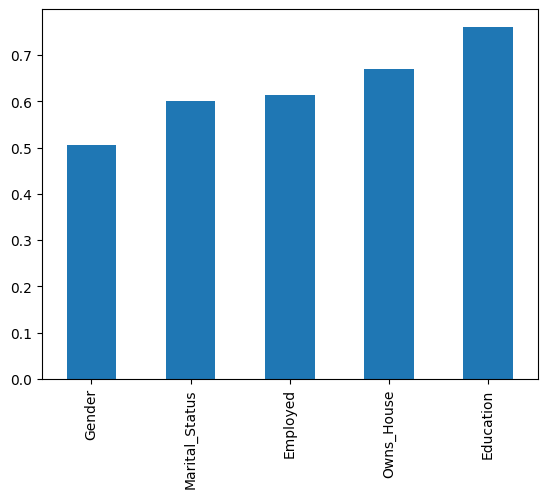

In [ ]:
sr.plot(kind ="bar")

In [ ]:
# Exactly! ✅

# Using SelectKBest(score_func=chi2, k=...) will:

# 🎯 Automatically compute Chi-Square scores for all features
# 🎯 Select the top k features based on those scores
# 🎯 Return a filtered version of your data (X_new) with only the best features

# ✅ So you don’t need to manually:
# Call chi2(X, y)

# Create DataFrames or Series


from sklearn.feature_selection import SelectKBest  , chi2 , VarianceThreshold ,f_classif

In [ ]:
ch = SelectKBest(chi2  , k = 2)

In [ ]:
x = data.iloc[:,:-1]
y= data.iloc[:,-1]
ch.fit(x,y)


SelectKBest(k=2, score_func=<function chi2 at 0x783ddef81f80>)

In [ ]:
cols = x.columns[ch.get_support()]


In [ ]:
pd.DataFrame(ch.transform(x) , columns = cols)

,Gender,Marital_Status
0,1,0
1,0,0
2,1,2
3,1,2
4,1,1
...,...,...
95,0,2
96,0,0
97,0,1
98,0,2


# WRAPPER METHODS

# EXHASTIVE METHOD

In [ ]:
!pip install --upgrade scikit-learn mlxtend


In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression , LogisticRegression
from sklearn.model_selection import cross_val_score
import pandas as pd

In [ ]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector as efs
from mlxtend.plotting import plot_sequential_feature_selection as sp

In [ ]:
lr = LogisticRegression()
ef = efs(lr , max_features = 4 , scoring = "accuracy" , cv= 5)

In [ ]:
data = load_iris().data
cols = load_iris().feature_names
df = pd.DataFrame(data = data , columns = cols)
df['Target']=load_iris().target
x =  df.iloc[:,:-1]

y = df.iloc[:,-1]
model = ef.fit(x,y)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Features: 15/15

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Number of Features', ylabel='Performance'>)

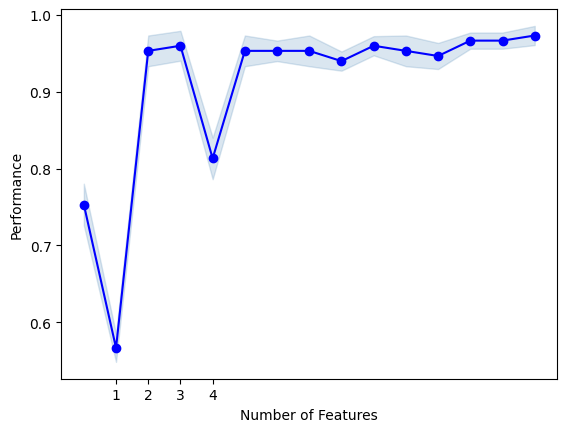

In [ ]:
sp(model.get_metric_dict(), kind = 'std_err')

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Features: 15/15

In [ ]:
model.best_feature_names_

('sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)')

In [ ]:
model.best_score_

np.float64(0.9733333333333334)

In [ ]:
model.subsets_

{0: {'feature_idx': (0,),
  'cv_scores': array([0.66666667, 0.73333333, 0.76666667, 0.76666667, 0.83333333]),
  'avg_score': np.float64(0.7533333333333333),
  'feature_names': ('sepal length (cm)',)},
 1: {'feature_idx': (1,),
  'cv_scores': array([0.53333333, 0.56666667, 0.53333333, 0.56666667, 0.63333333]),
  'avg_score': np.float64(0.5666666666666667),
  'feature_names': ('sepal width (cm)',)},
 2: {'feature_idx': (2,),
  'cv_scores': array([0.93333333, 1.        , 0.9       , 0.93333333, 1.        ]),
  'avg_score': np.float64(0.9533333333333334),
  'feature_names': ('petal length (cm)',)},
 3: {'feature_idx': (3,),
  'cv_scores': array([1.        , 0.96666667, 0.9       , 0.93333333, 1.        ]),
  'avg_score': np.float64(0.96),
  'feature_names': ('petal width (cm)',)},
 4: {'feature_idx': (0, 1),
  'cv_scores': array([0.73333333, 0.83333333, 0.76666667, 0.86666667, 0.86666667]),
  'avg_score': np.float64(0.8133333333333332),
  'feature_names': ('sepal length (cm)', 'sepal width

In [ ]:
dta = pd.DataFrame.from_dict(model.get_metric_dict()).T

In [ ]:
from mlxtend.plotting import plot_sequential_feature_selection as sp

In [ ]:
import matplotlib.pyplot as plt


0     0.753333
1     0.566667
2     0.953333
3         0.96
4     0.813333
5     0.953333
6     0.953333
7     0.953333
8         0.94
9         0.96
10    0.953333
11    0.946667
12    0.966667
13    0.966667
14    0.973333
Name: avg_score, dtype: object
0     0.753333
1     0.566667
2     0.953333
3         0.96
4     0.813333
5     0.953333
6     0.953333
7     0.953333
8         0.94
9         0.96
10    0.953333
11    0.946667
12    0.966667
13    0.966667
14    0.973333
Name: avg_score, dtype: object
0     0.753333
1     0.566667
2     0.953333
3         0.96
4     0.813333
5     0.953333
6     0.953333
7     0.953333
8         0.94
9         0.96
10    0.953333
11    0.946667
12    0.966667
13    0.966667
14    0.973333
Name: avg_score, dtype: object
0     0.753333
1     0.566667
2     0.953333
3         0.96
4     0.813333
5     0.953333
6     0.953333
7     0.953333
8         0.94
9         0.96
10    0.953333
11    0.946667
12    0.966667
13    0.966667
14    0.973333
Name: a

# SEQUENTIALLY BACKWARD

In [ ]:
from sklearn.datasets import make_regression
import pandas as pd

# Generate synthetic regression data
X, y = make_regression(n_samples=1000,     # 1000 rows
                       n_features=10,      # 10 features
                       n_informative=8,    # 8 are informative
                       noise=10.0,         # add noise to target
                       random_state=42)

# Create DataFrame
feature_names = [f'Feature_{i}' for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Display first 5 rows

In [ ]:
from mlxtend.feature_selection import  ExhaustiveFeatureSelector , SequentialFeatureSelector as sf
from sklearn.linear_model import LinearRegression , SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
import numpy as np

In [ ]:
lr = LinearRegression()
print("TRAIN R2 SCORE : ",np.mean(cross_val_score(lr , x_train , y_train , cv= 5 , scoring = "r2" )) )
print("TEST R2 SCORE : ",np.mean(cross_val_score(lr , x_test , y_test , cv= 5 , scoring = "r2" )) )

TRAIN R2 SCORE :  0.9915747313700182
TEST R2 SCORE :  0.9918088279382135


In [ ]:

y = df.iloc[:,-1]
x = df.iloc[:,:-1]

x_train , x_test ,y_train , y_test  = train_test_split(x,y , random_state = 12 , test_size = 0.3)

In [ ]:
model = sf(lr , k_features ="best" ,forward = False , floating = False  , scoring = 'r2', cv = 5 )

In [ ]:
model.fit(x_train , y_train)

,estimator,LinearRegression()
,k_features,"(1, ...)"
,forward,False
,floating,False
,verbose,0
,scoring,'r2'
,cv,5
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


In [ ]:
model.k_feature_idx_

(0, 1, 2, 3, 5, 6, 7, 8, 9)

In [ ]:
dft = pd.DataFrame.from_dict(model.get_metric_dict()).T
dft

,feature_idx,cv_scores,avg_score,feature_names,ci_bound,std_dev,std_err
10,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9)","[0.9887599156889113, 0.9927753551714091, 0.991...",0.991575,"(Feature_0, Feature_1, Feature_2, Feature_3, F...",0.001862,0.001449,0.000724
9,"(0, 1, 2, 3, 5, 6, 7, 8, 9)","[0.9887858902863195, 0.9927781945283665, 0.991...",0.991582,"(Feature_0, Feature_1, Feature_2, Feature_3, F...",0.00185,0.001439,0.00072
8,"(0, 1, 2, 3, 5, 6, 7, 8)","[0.9888014256124239, 0.9927854033763319, 0.991...",0.991563,"(Feature_0, Feature_1, Feature_2, Feature_3, F...",0.001834,0.001427,0.000714
7,"(0, 1, 2, 3, 5, 6, 7)","[0.9853935749573504, 0.9908404126441966, 0.989...",0.988994,"(Feature_0, Feature_1, Feature_2, Feature_3, F...",0.00243,0.001891,0.000945
6,"(0, 2, 3, 5, 6, 7)","[0.9780452138378237, 0.9865661531734432, 0.984...",0.98391,"(Feature_0, Feature_2, Feature_3, Feature_5, F...",0.003928,0.003056,0.001528
5,"(0, 2, 3, 5, 6)","[0.9631352158329752, 0.9814295817117697, 0.978...",0.975918,"(Feature_0, Feature_2, Feature_3, Feature_5, F...",0.008641,0.006723,0.003362
4,"(0, 2, 5, 6)","[0.9536690048913006, 0.9714868218805456, 0.967...",0.965348,"(Feature_0, Feature_2, Feature_5, Feature_6)",0.009071,0.007058,0.003529
3,"(0, 5, 6)","[0.8644483168354085, 0.8951099479615215, 0.867...",0.8717,"(Feature_0, Feature_5, Feature_6)",0.019344,0.015051,0.007525
2,"(0, 5)","[0.7298226400789926, 0.795617323092495, 0.7845...",0.774061,"(Feature_0, Feature_5)",0.03745,0.029137,0.014568
1,"(0,)","[0.5044886188113412, 0.43833799160064313, 0.51...",0.488894,"(Feature_0,)",0.05366,0.041749,0.020874


In [ ]:
# FOR ADJUSTED R2 SCORE
def adj(r2 , cols , rows):
  r2 = r2**2
  x =  (1-r2)*(rows-1) / (rows - 1 - cols)
  return (1-x)*100
dft['cols'] = dft['feature_idx'].apply(lambda x: len(x))
dft['adjustR2'] = adj(dft['avg_score'] ,dft['cols'],dft['obse'])


In [ ]:
dft['obse'] = 1000

In [ ]:
dft[['avg_score',"adjustR2"]]

,avg_score,adjustR2
10,0.991575,98.305079
9,0.991582,98.308241
8,0.991563,98.30624
7,0.988994,97.795389
6,0.98391,96.78867
5,0.975918,95.217661
4,0.965348,93.162392
3,0.8717,75.913838
2,0.774061,59.836613
1,0.488894,23.825441


In [ ]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Number of Features', ylabel='Performance'>)

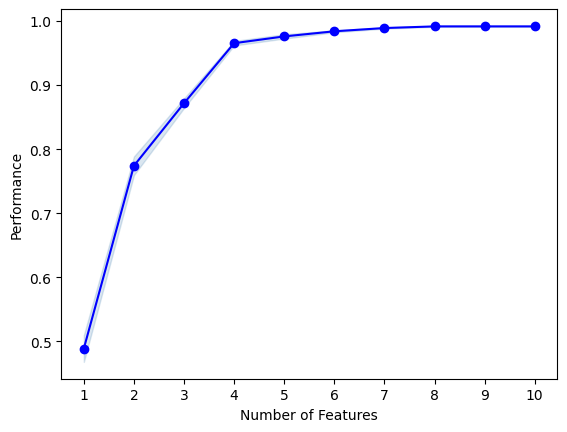

In [ ]:
plot_sfs(model.get_metric_dict() , kind = "std_err")

In [ ]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector
from mlxtend.feature_selection import SequentialFeatureSelector
from mlxtend.plotting import plot_sequential_feature_selection
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import chi2 , f_classif ,SelectKBest
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression , SGDRegressor , LogisticRegression

In [ ]:
iris = load_iris()


In [ ]:
x = iris.data
y = iris.target
cols= iris.feature_names
df = pd.DataFrame(data = x  ,columns = cols)


In [ ]:
df['Target']= pd.Series(data = iris.target_names[iris.target] )

# RECURSIVE FEATURE ELEMINATION

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

In [ ]:
lr = LogisticRegression(multi_class='multinomial',n_jobs=-1)
x = df.iloc[:,:-1]
y  = df.iloc[:,-1]

In [ ]:
y

,Target
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa
...,...
145,virginica
146,virginica
147,virginica
148,virginica


In [ ]:
x_train , x_test  , y_train , y_test = train_test_split(x, y , random_state = 13 , test_size = 13)

In [ ]:
rfe = RFE(estimator=lr  ,n_features_to_select=2)

In [ ]:
rfe.fit(x_train , y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


RFE(estimator=LogisticRegression(multi_class='multinomial', n_jobs=-1),
    n_features_to_select=2)

In [ ]:
cols = x_train.columns[rfe.get_support()]
array = rfe.transform(x_train)

x_train  = pd.DataFrame(data = array , columns = cols)


In [ ]:
array2 = rfe.transform(x_test)

In [ ]:
x_test = pd.DataFrame(data = array2 , columns = cols)

In [ ]:
x_test.shape

(13, 2)

In [ ]:
x_train.shape

(137, 2)

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
le.fit(y_train)

LabelEncoder()

In [ ]:
y_train_t = le.transform(y_train)
y_test_t = le.transform(y_test)

In [ ]:
lr.fit(x_train , y_train_t)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(multi_class='multinomial', n_jobs=-1)

In [ ]:
np.mean(cross_val_score(lr , x_train , y_train_t , cv = 5))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

np.float64(0.956084656084656)

In [ ]:
# np.mean(cross_val_score(lr , x_test, y_test_t , cv = 5))
x =lr.predict(x_test)
x.shape


(13,)

In [ ]:
np.mean(cross_val_score(lr , x_test , y_test_t ,cv= 5))

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default 

np.float64(0.9333333333333332)

(137, 2)

In [ ]:
x_train.shape

(137, 2)